### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

### **Dataset Loading**

In [5]:
# Load your preprocessed dataset from Project 2
df = pd.read_csv('/content/sample_data/titanic_preprocessed.csv')

print(df.shape)
print(df.head())
print(df.columns)

(891, 13)
   Survived  Pclass       Age     SibSp     Parch      Fare  FamilySize  \
0         0       3 -0.565736  0.432793 -0.473674 -0.502445    0.059160   
1         1       1  0.663861  0.432793 -0.473674  0.786845    0.059160   
2         1       3 -0.258337 -0.474545 -0.473674 -0.488854   -0.560975   
3         1       1  0.433312  0.432793 -0.473674  0.420730    0.059160   
4         0       3  0.433312 -0.474545 -0.473674 -0.486337   -0.560975   

   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Title_encoded  
0       False      True       False       False        True              4  
1        True     False        True       False       False              3  
2        True     False       False       False        True              2  
3        True     False       False       False        True              3  
4       False      True       False       False        True              4  
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
 

### **Features**

In [6]:
# Target variable
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (891, 12)
Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


### **Dataset Splitting** (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 712 samples
Test set: 179 samples


### **Train Logistic Regression Model**

In [8]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")
print(f"Model intercept: {model.intercept_[0]:.4f}")

Model trained successfully
Model intercept: 2.9218


### **Make predictions**

In [9]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

### **Performance Metrics**

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classification Metrics on Test Set:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Classification Metrics on Test Set:
Accuracy:  0.7989
Precision: 0.7568
Recall:    0.7568
F1-score:  0.7568


### Confusion Matrix

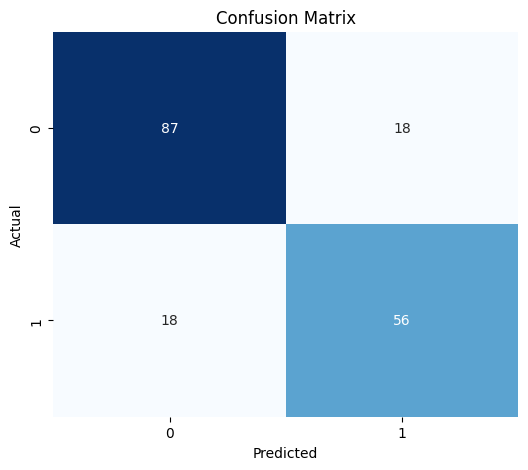

True Positives: 56
True Negatives: 87
False Positives: 18
False Negatives: 18


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

### **ROC Curve and AUC Score**

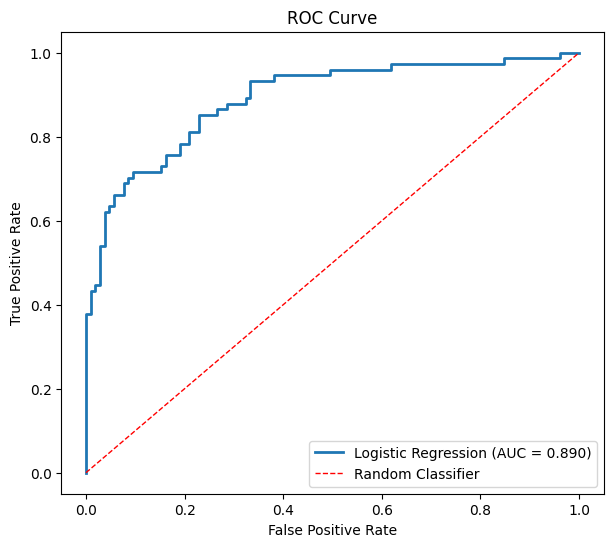

AUC Score: 0.8902


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc_score:.4f}")

In [13]:
print("Model Performance Summary:")
print(f"- The model correctly predicted {accuracy*100:.1f}% of cases.")
print(f"- Precision {precision:.3f}: When predicting survival, correct {precision*100:.1f}% of the time.")
print(f"- Recall {recall:.3f}: Found {recall*100:.1f}% of actual survivors.")
print(f"- F1-score {f1:.3f}: Balanced measure of precision and recall.")
print(f"- AUC {auc_score:.3f}: Model has {auc_score*100:.1f}% chance of distinguishing survivors from non-survivors.")

Model Performance Summary:
- The model correctly predicted 79.9% of cases.
- Precision 0.757: When predicting survival, correct 75.7% of the time.
- Recall 0.757: Found 75.7% of actual survivors.
- F1-score 0.757: Balanced measure of precision and recall.
- AUC 0.890: Model has 89.0% chance of distinguishing survivors from non-survivors.
